In [249]:
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

pd.set_option('display.max_columns', None)

In [250]:
@dataclass
class Selection:
    name: str
    mask: pd.Series
    events: int = field(init=False)
    interactions: int = field(init=False)

    def __post_init__(self):
        self.events = len(df[self.mask].groupby(level=[0, 1]).size())
        self.interactions = len(df[self.mask].groupby(level=[0, 1, 2]).size())

In [259]:
def broadcast_to_particles(interaction_mask, df):
    s = interaction_mask.loc[df.index.droplevel('rec.dlp.particles..index')]
    s.index = df.index
    return s

In [260]:
with pd.HDFStore('/exp/sbnd/app/users/micarrig/nueCCNp/cafpyana/test.df') as store:
    print(store.keys())

['/evt_0', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/hdr_7', '/hdr_8', '/hdr_9', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histgenevtdf_6', '/histgenevtdf_7', '/histgenevtdf_8', '/histgenevtdf_9', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/histpotdf_6', '/histpotdf_7', '/histpotdf_8', '/histpotdf_9', '/mcnu_0', '/nuecc_0', '/nuecc_1', '/nuecc_2', '/nuecc_3', '/nuecc_4', '/nuecc_5', '/nuecc_6', '/nuecc_7', '/nuecc_8', '/nuecc_9', '/pfp_0', '/pfp_1', '/pfp_2', '/pfp_3', '/pfp_4', '/pfp_5', '/pfp_6', '/pfp_7', '/pfp_8', '/pfp_9', '/pot_0', '/pot_1', '/pot_2', '/pot_3', '/pot_4', '/pot_5', '/pot_6', '/pot_7', '/pot_8', '/pot_9', '/split']


In [261]:
df = pd.read_hdf('/exp/sbnd/app/users/micarrig/nueCCNp/cafpyana/test.df', 'nuecc_0')

In [262]:
df

rec  \
                                                             dlp   
                                                       match_ids   
                                                                   
                                                                   
__ntuple entry rec.dlp..index rec.dlp.particles..index             
19       0     0              0                              0.0   
               1              0                              3.0   
                              1                              3.0   
               2              0                              NaN   
               5              0                              8.0   
...                                                          ...   
7        8660  12             0                             10.0   
               13             0                              1.0   
               14             0                              0.0   
                              1                              0.0   
               15             0                             13.0   

                                                                       \
                                                                        
                                                       match_overlaps   
                                                                        
                                                                        
__ntuple entry rec.dlp..index rec.dlp.particles..index                  
19       0     0              0                              0.149254   
               1              0                              0.673243   
                              1                              0.673243   
               2              0                                   NaN   
               5              0                              0.949460   
...                                                               ...   
7        8660  12             0                              0.520086   
               13             0                              0.996528   
               14             0                              0.889466   
                              1                              0.889466   
               15             0                              0.892857   

                                                                       \
                                                                        
                                                       cathode_offset   
                                                                        
                                                                        
__ntuple entry rec.dlp..index rec.dlp.particles..index                  
19       0     0              0                                  -inf   
               1              0                                  -inf   
                              1                                  -inf   
               2              0                                   NaN   
               5              0                             13.249988   
...                                                               ...   
7        8660  12             0                                  -inf   
               13             0                                  -inf   
               14             0                                  -inf   
                              1                                  -inf   
               15             0                                  -inf   

                                                                        \
                                                                         
                                                       depositions_sum   
                                                                         
                                                                         
__ntuple entry rec.dlp..index rec.dlp.particles..i

In [263]:
true_particle_idx = df.index.get_level_values('rec.dlp_true.particles..index')
true_prim_muon_mask = true_particle_idx == df.rec.dlp_true.primmm # get mask of only primary muons
true_prim_pion_mask = true_particle_idx == df.rec.dlp_true.primmp # get mask of only primary pions
true_prim_ele_mask = true_particle_idx == df.rec.dlp_true.primele # get mask of only primary electrons
true_prim_proton_mask = true_particle_idx == df.rec.dlp_true.primpr # get mask of only primary protons
true_prim_photon_mask = true_particle_idx == df.rec.dlp_true.primph # get mask of only primary photons


KeyError: 'Level rec.dlp_true.particles..index not found'

In [264]:
particle_idx = df.index.get_level_values('rec.dlp.particles..index') # get index for all particles
prim_muon_mask = particle_idx == df.rec.dlp.primmu # get mask of only primary muons
prim_pion_mask = particle_idx == df.rec.dlp.primpi # get mask of only primary pions
prim_ele_mask = particle_idx == df.rec.dlp.primele # get mask of only primary electrons
prim_proton_mask = particle_idx == df.rec.dlp.primpr # get mask of only primary protons
prim_photon_mask = particle_idx == df.rec.dlp.primph # get mask of only primary photons

all_mask = pd.Series(True, index=df.index) # mask of all particles

# preselection interaction level masks
fid_mask = df.rec.dlp['is_fiducial'] == 1
flash_mask = df.rec.dlp['is_flash_matched'] == 1
contained_mask = df.rec.dlp['is_contained'] == 1

# Particle level masks
muon_mask = (abs(df.rec.dlp.particles['pdg_code'] == 13) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 25.0))
pion_mask = (abs(df.rec.dlp.particles['pdg_code'] == 211) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 25.0))
photon_mask = (abs(df.rec.dlp.particles['pdg_code'] == 22) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 100.0))  
electron_mask = (abs(df.rec.dlp.particles['pdg_code'] == 11) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 500.0))
proton_mask = (abs(df.rec.dlp.particles['pdg_code'] == 2212) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 40.0))
electron_softmax_mask = df.rec.dlp.particles.pid_scores['I1'] > 0.9
electron_primary_mask = df.rec.dlp.particles.primary_scores['I0'] > 0.99
proton_softmax_mask = df.rec.dlp.particles.pid_scores['I4'] > 0.75
vertex_distance_mask = df.rec.dlp.particles.vertex_distance < 3.5
dedx_mask = df.rec.dlp.particles.start_dedx > 4.0

# Interaction level mask from particle level masks
int_muon_mask = broadcast_to_particles((prim_muon_mask & muon_mask).groupby(level=[0, 1, 2]).any(), df)
int_pion_mask = broadcast_to_particles((prim_pion_mask & pion_mask).groupby(level=[0, 1, 2]).any(), df)
int_ele_mask = broadcast_to_particles((prim_ele_mask & electron_mask).groupby(level=[0, 1, 2]).any(), df)
int_proton_mask = broadcast_to_particles((prim_proton_mask & proton_mask).groupby(level=[0, 1, 2]).any(), df)
int_photon_mask = broadcast_to_particles((prim_photon_mask & photon_mask).groupby(level=[0, 1, 2]).any(), df)
int_ele_sm_mask = broadcast_to_particles((prim_ele_mask & electron_softmax_mask).groupby(level=[0, 1, 2]).any(), df)
int_ele_primary_mask = broadcast_to_particles((prim_ele_mask & electron_primary_mask).groupby(level=[0, 1, 2]).any(), df)
int_proton_sm_mask = broadcast_to_particles((prim_proton_mask & proton_softmax_mask).groupby(level=[0, 1, 2]).any(), df)
int_vertex_distance_mask = broadcast_to_particles((prim_ele_mask & vertex_distance_mask).groupby(level=[0, 1, 2]).any(), df)
int_dedx_mask = broadcast_to_particles((prim_ele_mask & dedx_mask).groupby(level=[0, 1, 2]).any(), df)

In [265]:
selections = []

selections.append(Selection(name='No Selection', mask=all_mask))
selections.append(Selection(name='Fiducial Volume', mask=fid_mask))
selections.append(Selection(name='Flash Matched', mask=flash_mask))
selections.append(Selection(name='Contained', mask=contained_mask))
selections.append(Selection(name='No Muons', mask=~int_muon_mask))
selections.append(Selection(name='No Pions', mask=~int_pion_mask))
selections.append(Selection(name='Electron > 500 MeV', mask=int_ele_mask))
selections.append(Selection(name='Proton > 40 MeV', mask=int_proton_mask))
selections.append(Selection(name='No Photons', mask=~int_photon_mask))

In [266]:
W = 28  # column width for metric columns

header = (f"{'Selection':<30} {'Events':>10} {'Ints':>10} "
          f"{'Diff. Eff.':>{W}} {'Cum. Eff.':>{W}} {'Purity':>{W}}")
print(header)
print("-" * len(header))

combined_sel = all_mask.copy()
signal = df.rec.dlp_true.true_signal1p | df.rec.dlp_true.true_signalNp
signal_interactions = len(df[signal].groupby(level=[0, 1, 2]).size())

for sel in selections:
    combined_sel &= sel.mask
    evts     = len(df[sel.mask].groupby(level=[0, 1]).size())
    ints     = len(df[sel.mask].groupby(level=[0, 1, 2]).size())
    sig_ints = len(df[sel.mask & signal].groupby(level=[0, 1, 2]).size())
    ints_cum     = len(df[combined_sel].groupby(level=[0, 1, 2]).size())
    cum_sig_ints = len(df[combined_sel & signal].groupby(level=[0, 1, 2]).size())

    diff_eff = sig_ints / signal_interactions if signal_interactions > 0 else 0
    cum_eff  = cum_sig_ints / signal_interactions if signal_interactions > 0 else 0
    purity   = cum_sig_ints / ints_cum if ints_cum > 0 else 0

    diff_str = f"{diff_eff:.1%} ({sig_ints}/{signal_interactions})"
    cum_str  = f"{cum_eff:.1%} ({cum_sig_ints}/{signal_interactions})"
    pur_str  = f"{purity:.1%} ({cum_sig_ints}/{ints_cum})"

    print(f"{sel.name:<30} {evts:>10} {ints:>10} "
          f"{diff_str:>{W}} {cum_str:>{W}} {pur_str:>{W}}")

Selection                          Events       Ints                   Diff. Eff.                    Cum. Eff.                       Purity
-------------------------------------------------------------------------------------------------------------------------------------------
No Selection                        16870     188269               100.0% (19/19)               100.0% (19/19)             0.0% (19/188269)
Fiducial Volume                     16524      66792               100.0% (19/19)               100.0% (19/19)              0.0% (19/66792)
Flash Matched                       16412      16750               100.0% (19/19)               100.0% (19/19)               0.2% (19/9588)
Contained                           14547      32977                94.7% (18/19)                94.7% (18/19)               0.3% (18/5712)
No Muons                            15524      44630               100.0% (19/19)                94.7% (18/19)               0.6% (18/2955)
No Pions            

In [177]:
evts = df.groupby(level=[0, 1]).size() #number of events
interactions = df.groupby(level=[0, 1, 2]).size() #number of interactions
particles = df.groupby(level=[0, 1, 2, 3]).size() #number of particles

print("Total Events: ", len(evts))
print("Total Interactions: ", len(interactions))
print("Total Particles: ", len(particles))

Total Events:  8832
Total Interactions:  98639
Total Particles:  324845


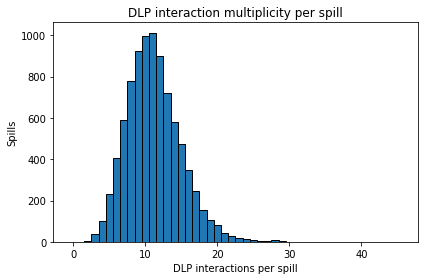

In [122]:
interactions_per_spill = df.groupby(level=[0, 1, 2]).size()  # one row per interaction
counts = interactions_per_spill.groupby(level=[0, 1]).size()  # count interactions per spill

fig, ax = plt.subplots()
ax.hist(counts, bins=range(counts.max() + 2), align='left', edgecolor='black')
ax.set_xlabel('DLP interactions per spill')
ax.set_ylabel('Spills')
ax.set_title('DLP interaction multiplicity per spill')
plt.tight_layout()
plt.show()

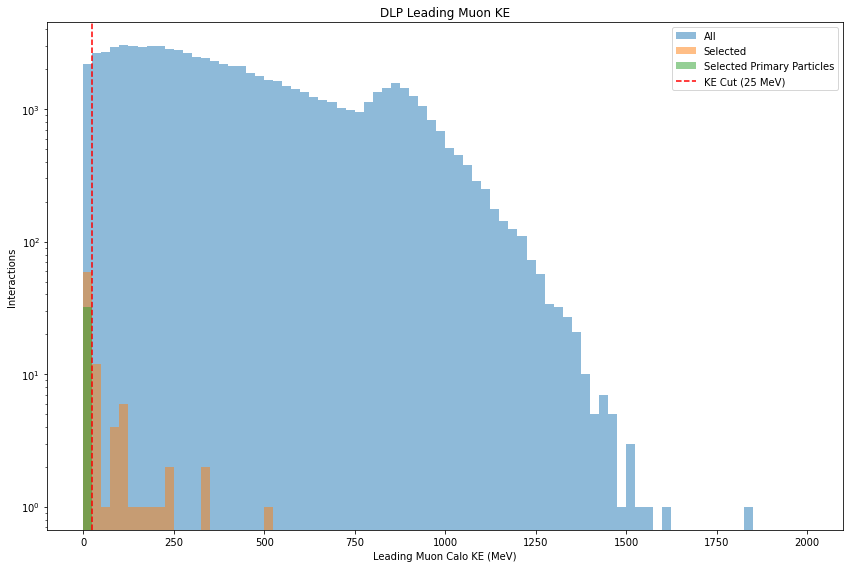

In [153]:
particle_idx = df.index.get_level_values('rec.dlp.particles..index')
prim_muon_mask = particle_idx == df.rec.dlp.primmu

muon_ke = df.rec.dlp.particles.calo_ke[prim_muon_mask]

sel_mask = fid_mask & flash_mask & contained_mask & ~muon_mask
muon_sel = sel_mask & prim_muon_mask

primary_mask = df.rec.dlp.particles.is_primary == 1

muon_ke_sel = df.rec.dlp.particles.calo_ke[muon_sel]

prim_muon_ke_sel = df.rec.dlp.particles.calo_ke[muon_sel & primary_mask]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.hist(muon_ke, bins=80, range=(0, 2000), alpha=0.5, label='All')
ax.hist(muon_ke_sel, bins=80, range=(0, 2000), alpha=0.5, label='Selected')
ax.hist(prim_muon_ke_sel, bins=80, range=(0, 2000), alpha=0.5, label='Selected Primary Particles')
ax.set_xlabel('Leading Muon Calo KE (MeV)')
ax.set_ylabel('Interactions')
ax.set_title('DLP Leading Muon KE')
plt.tight_layout()
plt.yscale('log')

plt.axvline(25.0, color='red', linestyle='--', label='KE Cut (25 MeV)')
plt.legend()

plt.show()


In [144]:
df[~muon_mask]

rec  \
                                                             dlp   
                                                       match_ids   
                                                                   
                                                                   
__ntuple entry rec.dlp..index rec.dlp.particles..index             
0        0     0              0                              5.0   
                              1                              5.0   
               1              0                              0.0   
               2              0                              4.0   
                              1                              4.0   
...                                                          ...   
         8831  22             1                              0.0   
                              2                              0.0   
                              3                              0.0   
                              4                              0.0   
               23             0                             17.0   

                                                                       \
                                                                        
                                                       match_overlaps   
                                                                        
                                                                        
__ntuple entry rec.dlp..index rec.dlp.particles..index                  
0        0     0              0                              0.341244   
                              1                              0.341244   
               1              0                              0.938068   
               2              0                              0.928590   
                              1                              0.928590   
...                                                               ...   
         8831  22             1                              0.896471   
                              2                              0.896471   
                              3                              0.896471   
                              4                              0.896471   
               23             0                              0.769231   

                                                                       \
                                                                        
                                                       cathode_offset   
                                                                        
                                                                        
__ntuple entry rec.dlp..index rec.dlp.particles..index                  
0        0     0              0                                  -inf   
                              1                                  -inf   
               1              0                             -0.250012   
               2              0                                  -inf   
                              1                                  -inf   
...                                                               ...   
         8831  22             1                                  -inf   
                              2                                  -inf   
                              3                                  -inf   
                              4                                  -inf   
               23             0                                  -inf   

                                                                        \
                                                                         
                                                       depositions_sum   
                                                                         
                                                                         
__ntuple entry rec.dlp..index rec.dlp.particles..i